**PART 1: Setup, EDA & GAN-Based Augmentation**

Install Required Libraries

In [ ]:
!pip install -q kaggle
import os

In [ ]:
!unzip -q "/content/archive (5).zip" -d "/content/asl_dataset"

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import random
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten, Dropout,
                                     Reshape, BatchNormalization, LeakyReLU, UpSampling2D, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
train_df = pd.read_csv("/content/asl_dataset/sign_mnist_train.csv")
test_df = pd.read_csv("/content/asl_dataset/sign_mnist_test.csv")

X_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_train = train_df['label'].values
X_test = test_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_test = test_df['label'].values

y_train_cat = to_categorical(y_train, num_classes=25)
y_test_cat = to_categorical(y_test, num_classes=25)

Preview Sample Images

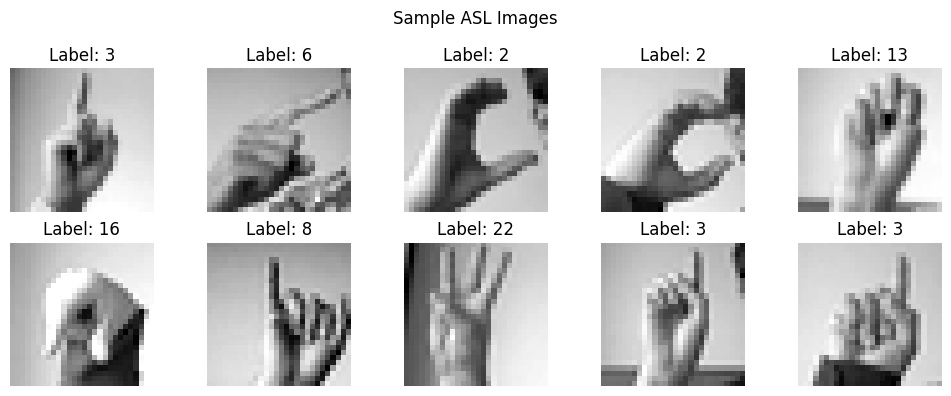

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample ASL Images")
plt.tight_layout()
plt.show()

**EDA – Class & Pixel Intensity Analysis**

Class Distribution

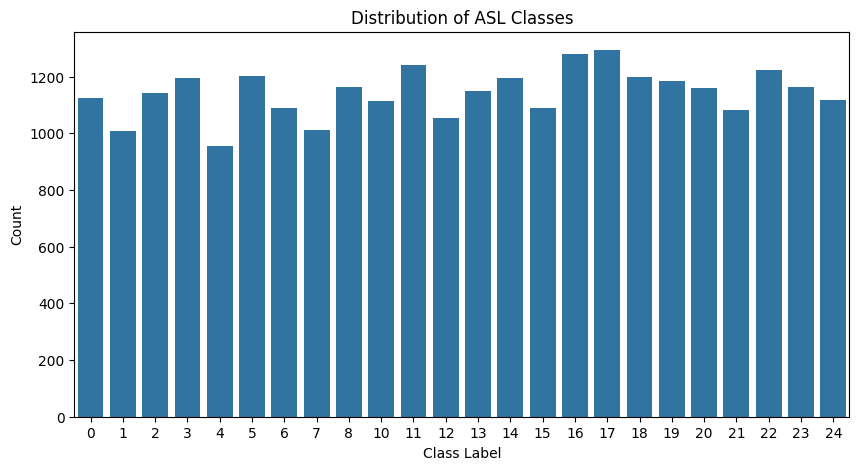

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train)
plt.title("Distribution of ASL Classes")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

Pixel intensity

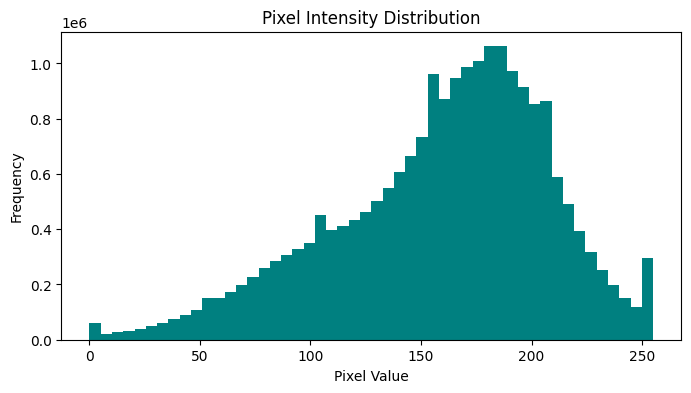

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(X_train.flatten()*255, bins=50, color='teal')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Mean & std deviation of pixel intensity

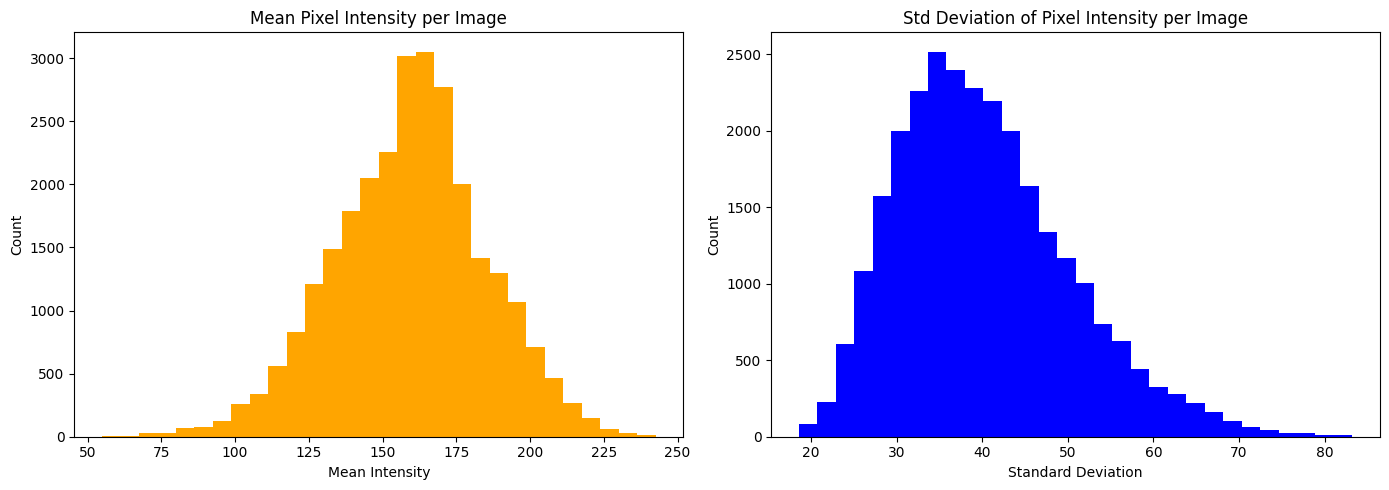

In [ ]:
mean_intensity = X_train.reshape(len(X_train), -1).mean(axis=1) * 255
std_intensity = X_train.reshape(len(X_train), -1).std(axis=1) * 255

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(mean_intensity, bins=30, color='orange')
plt.title("Mean Pixel Intensity per Image")
plt.xlabel("Mean Intensity")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(std_intensity, bins=30, color='blue')
plt.title("Std Deviation of Pixel Intensity per Image")
plt.xlabel("Standard Deviation")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

PART 3: AUGMENTATION USING IMAGEDATAGENERATOR

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False  # Don't flip ASL signs
)

datagen.fit(X_train)

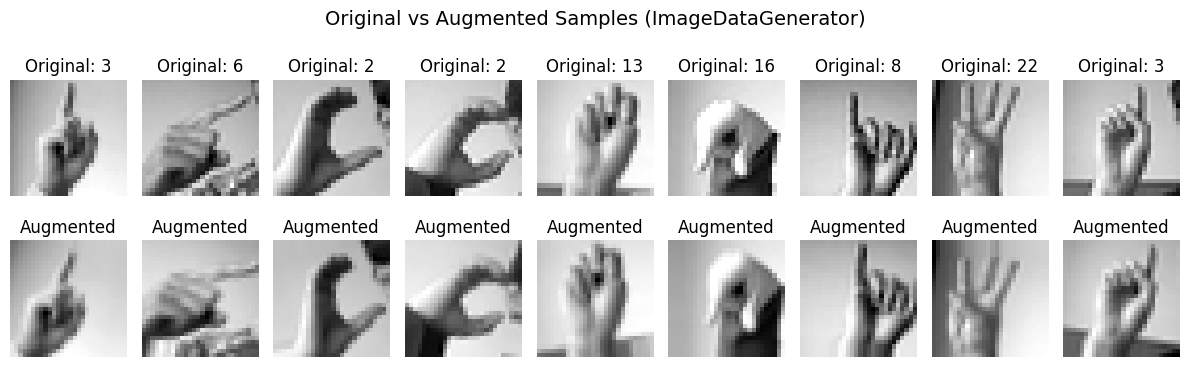

In [ ]:
#Generate a batch of augmented images from the first 9 samples
sample_images = X_train[:9]
sample_labels = y_train[:9]

#Create a generator with 1 batch (for display only)
augmented_batch = datagen.flow(sample_images, sample_labels, batch_size=9, shuffle=False)

augmented_images, augmented_labels = next(augmented_batch)

#Plot the original vs augmented images
plt.figure(figsize=(12, 4))
for i in range(9):
    #Original
    plt.subplot(2, 9, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original: {sample_labels[i]}")
    plt.axis('off')

    #Augmented
    plt.subplot(2, 9, i + 10)
    plt.imshow(augmented_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Augmented")
    plt.axis('off')

plt.suptitle("Original vs Augmented Samples (ImageDataGenerator)", fontsize=14)
plt.tight_layout()
plt.show()

The visual augmentation from ImageDataGenerator is intentionally subtle to preserve the integrity of hand signs. While changes aren't always visually striking, these micro-transformations (shifts, zooms, slight rotations) introduce essential variability that helps the CNN generalize better, especially in low-resource environments where GAN-based approaches are computationally expensive.

In [ ]:
#Combine original and augmented data
X_train_augmented = np.concatenate([X_train, augmented_images])
y_train_augmented = np.concatenate([y_train, augmented_labels])

#One-hot encode updated labels
y_train_aug_cat = to_categorical(y_train_augmented, num_classes=25)
y_test_cat = to_categorical(y_test, num_classes=25)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(25, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/30
172/172 - 37s - 212ms/step - accuracy: 0.8348 - loss: 0.4789 - val_accuracy: 0.9765 - val_loss: 0.1323
Epoch 2/30
172/172 - 37s - 215ms/step - accuracy: 0.8682 - loss: 0.3847 - val_accuracy: 0.9860 - val_loss: 0.0916
Epoch 3/30
172/172 - 42s - 241ms/step - accuracy: 0.8936 - loss: 0.3135 - val_accuracy: 0.9927 - val_loss: 0.0635
Epoch 4/30
172/172 - 40s - 230ms/step - accuracy: 0.9065 - loss: 0.2784 - val_accuracy: 0.9965 - val_loss: 0.0404
Epoch 5/30
172/172 - 31s - 183ms/step - accuracy: 0.9195 - loss: 0.2348 - val_accuracy: 0.9987 - val_loss: 0.0269
Epoch 6/30
172/172 - 33s - 191ms/step - accuracy: 0.9321 - loss: 0.2049 - val_accuracy: 0.9982 - val_loss: 0.0212
Epoch 7/30
172/172 - 31s - 182ms/step - accuracy: 0.9413 - loss: 0.1877 - val_accuracy: 0.9998 - val_loss: 0.0159
Epoch 8/30
172/172 - 32s - 189ms/step - accuracy: 0.9470 - loss: 0.1654 - val_accuracy: 0.9998 - val_loss: 0.0114
Epoch 9/30
172/172 - 40s - 231ms/step - accuracy: 0.9550 - loss: 0.1424 - val_accuracy: 

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,901 (2.34 MB)

 Trainable params: 204,633 (799.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 409,268 (1.56 MB)

In [ ]:
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {acc * 100:.2f}%")

Test Accuracy: 96.95%


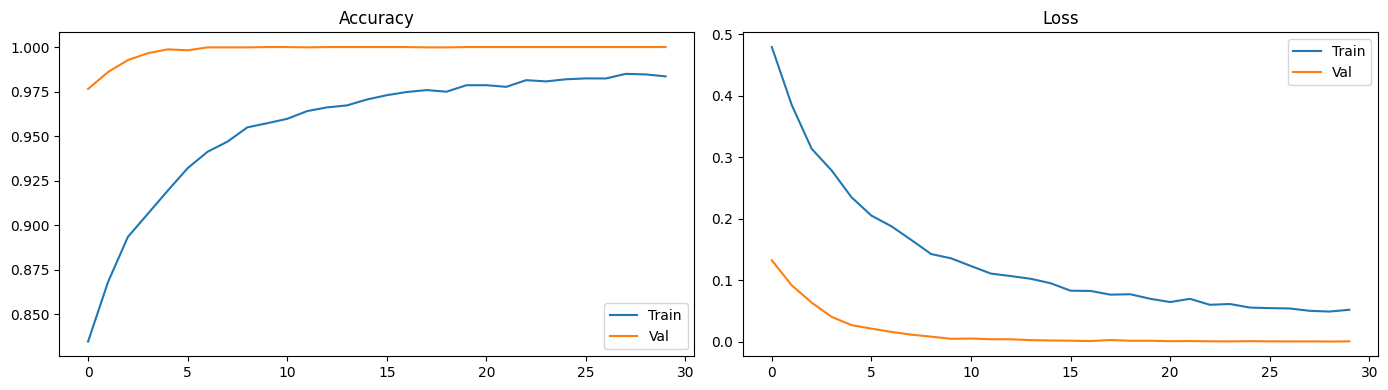

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      0.99      1.00       432
           2       0.88      0.93      0.90       310
           3       1.00      1.00      1.00       245
           4       0.99      0.99      0.99       498
           5       1.00      1.00      1.00       247
           6       0.94      0.96      0.95       348
           7       0.97      0.95      0.96       436
           8       0.99      0.96      0.97       288
          10       0.99      1.00      0.99       331
          11       1.00      1.00      1.00       209
          12       1.00      1.00      1.00       394
          13       1.00      0.99      1.00       291
          14       0.91      0.84      0.87       246
          15       1.00      1.00      1.00       347
          16       1.00      1.00      1.00       164
          17       0.94      0.72      

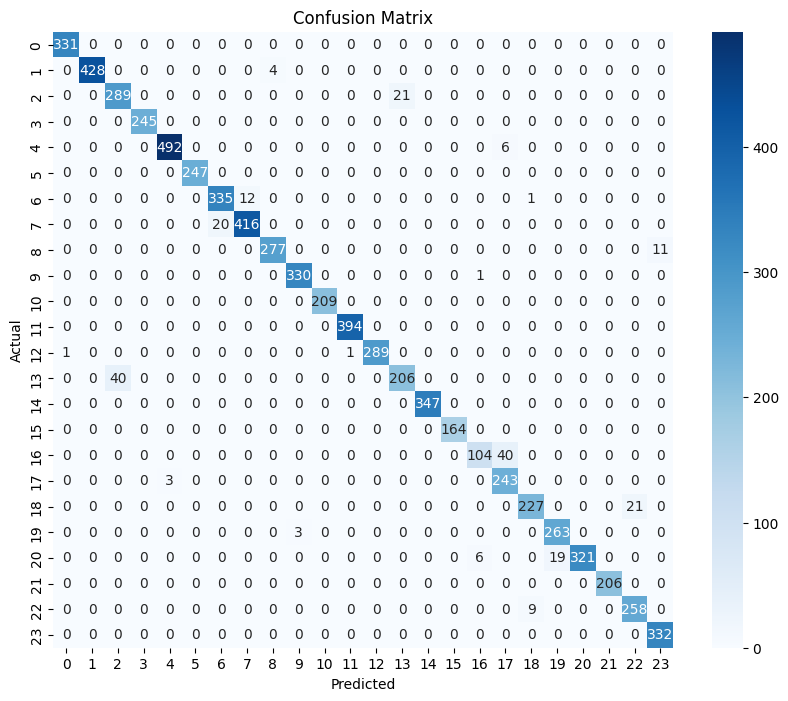

In [ ]:
#Classification Report
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_labels))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

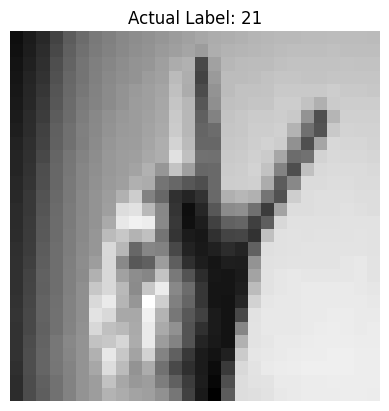

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Label: 21 (Confidence: 100.00%)


In [ ]:
#View the actual image and label
plt.imshow(X_test[5].reshape(28,28), cmap='gray')
plt.title(f"Actual Label: {y_test[5]}")
plt.axis('off')
plt.show()

#Predict using the model
sample = X_test[5].reshape(1,28,28,1)
pred = model.predict(sample)
predicted_label = np.argmax(pred)

print(f"Predicted Label: {predicted_label} (Confidence: {np.max(pred)*100:.2f}%)")


In [ ]:
labels = list("ABCDEFGHIKLMNOPQRSTUVWXY")  # J and Z skipped
actual_letter = labels[y_test[5]]
predicted_letter = labels[predicted_label]

print(f"Actual: {actual_letter} | Predicted: {predicted_letter}")

Actual: W | Predicted: W


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


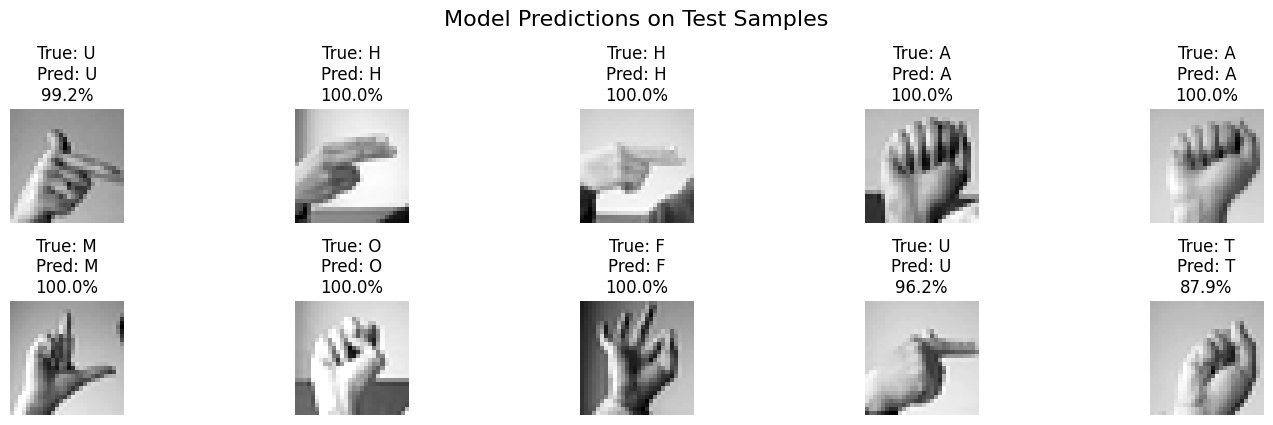

In [ ]:
labels = list("ABCDEFGHIKLMNOPQRSTUVWXY")

#Choose how many samples to test
num_samples = 10
indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15, 4))

for i, idx in enumerate(indices):
    image = X_test[idx].reshape(1, 28, 28, 1)
    true_label = y_test[idx]

    #Prediction
    pred = model.predict(image)
    pred_label = np.argmax(pred)

    #Display
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {labels[true_label]}\nPred: {labels[pred_label]}\n{np.max(pred)*100:.1f}%")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Model Predictions on Test Samples", fontsize=16, y=1.05)
plt.show()

REAL-TIME WEBCAM DETECTION

In [ ]:
from base64 import b64decode
from PIL import Image, ImageOps
import io
import string
import ipywidgets as widgets
from google.colab import output
from IPython.display import display, Javascript

In [ ]:
labels = list(string.ascii_uppercase)
labels.remove('J')
labels.remove('Z')

In [ ]:
def preprocess_frame(data_url):
    try:
        image_data = b64decode(data_url.split(',')[1])
        image = Image.open(io.BytesIO(image_data)).convert('L')
        image = ImageOps.invert(image)
        image = image.resize((28, 28))
        image_np = np.array(image).reshape(1, 28, 28, 1) / 255.0
        return image_np
    except Exception as e:
        print("Frame Error:", e)
        return None

In [ ]:
def get_frame(data_url):
    frame = preprocess_frame(data_url)
    if frame is not None:
        pred = model.predict(frame)
        idx = np.argmax(pred)
        letter = labels[idx]
        print(f"Predicted: {letter}")
        return {'result': 'continue'}
    else:
        return {'result': 'quit'}

In [ ]:
output.register_callback('notebook.getFrame', get_frame)

In [ ]:
def capture_video():
    display(Javascript('''
        async function captureVideo() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const context = canvas.getContext('2d');

            video.style.display = 'block';
            video.style.maxWidth = '480px';
            document.body.appendChild(video);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await new Promise((resolve) => video.onloadedmetadata = resolve);
            await video.play();

            const [track] = stream.getVideoTracks();
            const settings = track.getSettings();
            canvas.width = settings.width;
            canvas.height = settings.height;

            async function stopVideo() {
                stream.getTracks().forEach(track => track.stop());
                video.remove();
                canvas.remove();
            }

            window.stopVideo = stopVideo;

            while (true) {
                context.drawImage(video, 0, 0, canvas.width, canvas.height);
                const imageData = canvas.toDataURL('image/jpeg', 0.8);
                const response = await google.colab.kernel.invokeFunction('notebook.getFrame', [imageData], {});
                if (response.data.result === 'quit') break;
                await new Promise((resolve) => setTimeout(resolve, 500));
            }

            stopVideo();
        }
        captureVideo();
    '''))

In [ ]:
def stop_video(change):
    output.eval_js("""
        window.stopVideo();
        google.colab.kernel.invokeFunction('notebook.getFrame', ['data:image/jpeg;base64,'], {});
    """)

In [ ]:
stop_button = widgets.Button(description="Stop Video")
stop_button.on_click(stop_video)

In [ ]:
capture_video()
display(stop_button)

<IPython.core.display.Javascript object>

Button(description='Stop Video', style=ButtonStyle())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted: Q
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted: Q
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted: Q
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted: Q
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted: Q
